# 🏎️ F1 Playground Series S6E5 — Detailed EDA, Feature Engineering & Model Comparison

## Executive Summary — START HERE

**Goal:** predict `PitNextLap` and maximize **ROC-AUC**.

This notebook is presentation-ready: every major analysis contains a chart/table followed by an interpretation of **what the numbers mean, what they say about the dataset, why the finding matters, and what modeling action follows**.

### Key findings from the supplied data

| Finding | Evidence | Meaning / action |
|---|---:|---|
| Target imbalance | ~80.10% negative / ~19.90% positive | ROC-AUC is primary; accuracy is misleading |
| 2023 anomaly | ~0.96% positive vs ~26.7–29.5% other years | Investigate year-aware validation and regime effects |
| Stint | univariate AUC ≈ 0.747 | Very strong strategic-state signal |
| LapNumber | univariate AUC ≈ 0.702 | Strong race-stage signal |
| TyreLife | univariate AUC ≈ 0.699 | Strong tyre-age signal; nonlinear effects |
| RaceProgress | clear hump-shaped pit window | Use nonlinear race-stage features |
| LapNumber ↔ RaceProgress | Spearman ρ ≈ 0.98 | Highly redundant race-stage variables |
| Race | raw rates roughly 9%–39% | Circuit strategy matters |
| Compound | Hard ≈ 32.75%, Wet ≈ 2.51% raw | Strongly confounded; use interactions |
| Driver | 887 unique values | High-cardinality; use CatBoost or leakage-safe encoding |
| Missing values | 0 | No basic imputation required |
| Duplicate feature rows | 0 | No obvious duplicate leakage |
| Extreme values | LapTime max ≈ 2507.6; degradation has extreme tails | Test clipping/indicators, don't blindly delete |

### Modeling story

1. Baseline Logistic Regression
2. Random Forest
3. LightGBM (if installed)
4. XGBoost (if installed)
5. CatBoost (if installed)
6. Feature-engineered boosting models
7. Race-aware validation
8. ROC curves, AUC comparison, feature importance and final recommendation

### Core presentation message

> **Pit-stop behavior is primarily a structured race-strategy problem: race stage + tyre age + stint + compound + circuit + driver context.**

> **The 2023 target distribution is a major anomaly and must be explicitly investigated when interpreting validation scores.**


## 0. Presentation storyline

**Competition objective → data quality → target imbalance → anomaly discovery → univariate signals → interactions → train/test drift → sequence logic → feature engineering → validation → model comparison → ROC-AUC → explainability → final recommendation.**

## 1. Imports and configuration

In [1]:
# If needed, install: %pip install -q lightgbm xgboost catboost
import warnings, os, time, math, gc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
RANDOM_STATE=42
pd.set_option('display.max_columns',100)


## 2. Load the supplied files

In [2]:
TRAIN_PATH=r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\train.csv"
TEST_PATH=r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\test.csv"
SAMPLE_PATH=r"D:\Work\DSA_Coding_Questions\F1_Pit_prediction\data\sample_submission.csv"
train=pd.read_csv(TRAIN_PATH)
test=pd.read_csv(TEST_PATH)
sample_submission=pd.read_csv(SAMPLE_PATH)
print("Train:",train.shape,"Test:",test.shape,"Sample:",sample_submission.shape)
display(train.head())
display(test.head())
display(sample_submission.head())


Train: (439140, 16) Test: (188165, 15) Sample: (188165, 2)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


### Interpretation
The train set contains the target; test does not. The sample submission defines the required output structure. The notebook always recalculates statistics from the CSVs instead of hard-coding presentation numbers.

## 3. Schema, missingness, duplicates and cardinality

In [3]:
print(train.dtypes.to_frame('dtype'))
missing=train.isna().sum().sort_values(ascending=False)
display(pd.DataFrame({'missing':missing,'missing_pct':100*missing/len(train)}))
print('Exact duplicate rows:',train.duplicated().sum())
print('Duplicate feature rows excluding id:',train.drop(columns=['id'],errors='ignore').duplicated().sum())
card=pd.DataFrame({'dtype':train.dtypes.astype(str),'n_unique':train.nunique(),'unique_pct':100*train.nunique()/len(train)})
display(card.sort_values('n_unique',ascending=False))


                          dtype
id                        int64
Driver                      str
Compound                    str
Race                        str
Year                      int64
PitStop                   int64
LapNumber                 int64
Stint                     int64
TyreLife                float64
Position                  int64
LapTime (s)             float64
LapTime_Delta           float64
Cumulative_Degradation  float64
RaceProgress            float64
Position_Change         float64
PitNextLap              float64


,missing,missing_pct
id,0,0.0
Driver,0,0.0
Compound,0,0.0
Race,0,0.0
Year,0,0.0
PitStop,0,0.0
LapNumber,0,0.0
Stint,0,0.0
TyreLife,0,0.0
Position,0,0.0


Exact duplicate rows: 0
Duplicate feature rows excluding id: 0


,dtype,n_unique,unique_pct
id,int64,439140,100.000000
Cumulative_Degradation,float64,142701,32.495560
LapTime_Delta,float64,57532,13.101061
LapTime (s),float64,37719,8.589288
RaceProgress,float64,1898,0.432208
Driver,str,887,0.201986
LapNumber,int64,78,0.017762
TyreLife,float64,78,0.017762
Position_Change,float64,37,0.008426
Race,str,26,0.005921


### Interpretation
**0 missing values** means ordinary imputation is unnecessary. **0 exact feature duplicates** means there is no obvious duplicate leakage. High-cardinality fields such as Driver require careful encoding; naive target encoding can leak validation information.

## 4. Target distribution

,count,pct
PitNextLap,,
0.0,351759,80.102
1.0,87381,19.898


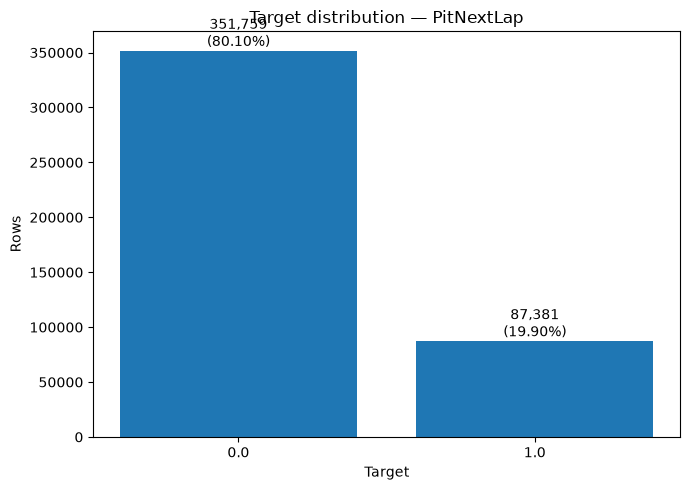

Positive:negative ratio = 0.2484115545018038


In [4]:
target='PitNextLap'
vc=train[target].value_counts().sort_index(); vp=100*vc/len(train)
display(pd.DataFrame({'count':vc,'pct':vp.round(3)}))
plt.figure(figsize=(7,5)); b=plt.bar(vc.index.astype(str),vc.values)
plt.title('Target distribution — PitNextLap'); plt.xlabel('Target'); plt.ylabel('Rows')
for x,n,p in zip(b,vc.values,vp): plt.text(x.get_x()+x.get_width()/2,n,f'{n:,}\n({p:.2f}%)',ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('Positive:negative ratio =',vc[1]/vc[0])


### Interpretation
The positive class is about **19.90%** and the negative class about **80.10%**, roughly a **4:1 imbalance**. A model predicting no-pit everywhere could look good on accuracy, so ROC-AUC is the correct primary ranking metric. PR-AUC is also useful as a secondary metric.

## 5. Numeric summary and outliers

In [5]:
num=[c for c in train.select_dtypes(include=np.number).columns if c!=target]
display(train[num].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T)
rows=[]
for c in num:
 q1,q3=train[c].quantile([.25,.75]); iqr=q3-q1; lo,hi=q1-1.5*iqr,q3+1.5*iqr
 n=((train[c]<lo)|(train[c]>hi)).sum(); rows.append([c,n,100*n/len(train),train[c].min(),train[c].max()])
display(pd.DataFrame(rows,columns=['feature','outliers','outlier_pct','min','max']).sort_values('outlier_pct',ascending=False))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
id,439140.0,219569.500000,126768.942943,0.000000,4391.390000,21956.950000,109784.75000,219569.500000,329354.250000,417182.050000,434747.610000,439139.000
Year,439140.0,2023.523544,1.024930,2022.000000,2022.000000,2022.000000,2023.00000,2024.000000,2024.000000,2025.000000,2025.000000,2025.000
PitStop,439140.0,0.136118,0.342915,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000
LapNumber,439140.0,23.105909,16.958261,1.000000,1.000000,2.000000,9.00000,19.000000,36.000000,54.000000,66.000000,78.000
Stint,439140.0,1.789113,0.950194,1.000000,1.000000,1.000000,1.00000,2.000000,2.000000,4.000000,5.000000,8.000
TyreLife,439140.0,14.158231,9.801338,1.000000,1.000000,2.000000,6.00000,12.000000,20.000000,32.000000,43.000000,77.000
Position,439140.0,9.630339,5.278770,1.000000,1.000000,1.000000,5.00000,10.000000,14.000000,18.000000,20.000000,20.000
LapTime (s),439140.0,90.948735,19.772769,67.694000,70.723000,75.053000,82.62100,90.521000,98.471000,109.726050,124.900000,2507.607
LapTime_Delta,439140.0,-3.770040,43.945759,-2403.895000,-40.256880,-24.819000,-8.88400,-0.295000,0.115000,19.026000,30.932000,2423.932
Cumulative_Degradation,439140.0,-25.721759,54.766573,-274.564000,-205.034000,-104.789250,-46.56625,-20.994000,-6.199000,84.401000,122.154000,2412.026


,feature,outliers,outlier_pct,min,max
11,Position_Change,61180,13.931776,-18.000000,18.000
2,PitStop,59775,13.611832,0.000000,1.000
8,LapTime_Delta,58900,13.412579,-2403.895000,2423.932
9,Cumulative_Degradation,49869,11.356060,-274.564000,2412.026
4,Stint,24078,5.482989,1.000000,8.000
7,LapTime (s),5905,1.344674,67.694000,2507.607
5,TyreLife,5711,1.300496,1.000000,77.000
3,LapNumber,16,0.003643,1.000000,78.000
0,id,0,0.000000,0.000000,439139.000
1,Year,0,0.000000,2022.000000,2025.000


### Interpretation
The data contains extreme numerical tails, especially `LapTime`, `LapTime_Delta` and `Cumulative_Degradation`. These are rare enough that we should **test** clipping/winsorization rather than delete observations blindly. Tree models can often handle the raw values.

## 6. Year anomaly — critical discovery

,count,sum,mean,positive_pct
Year,,,,
2022,82989,22117.0,0.266505,26.650520
2023,136147,1308.0,0.009607,0.960726
2024,127110,37538.0,0.295319,29.531902
2025,92894,26418.0,0.284389,28.438866


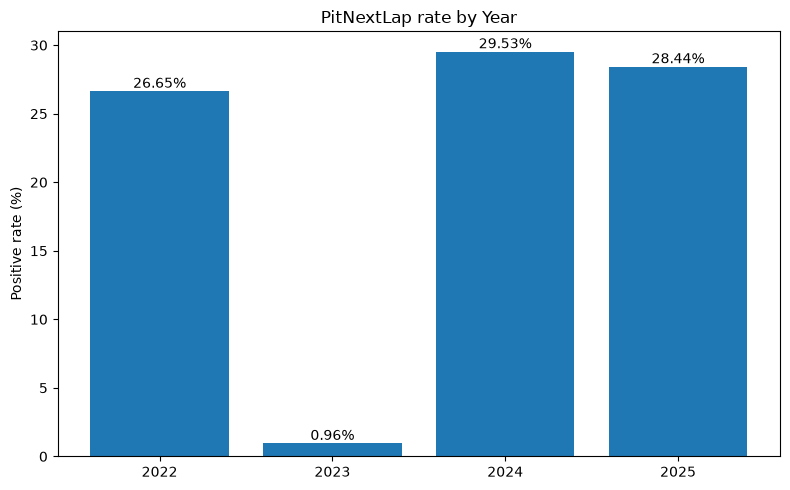

In [6]:
ys=train.groupby('Year')[target].agg(['count','sum','mean']); ys['positive_pct']=100*ys['mean']; display(ys)
plt.figure(figsize=(8,5)); b=plt.bar(ys.index.astype(str),ys.positive_pct); plt.title('PitNextLap rate by Year'); plt.ylabel('Positive rate (%)')
for x,v in zip(b,ys.positive_pct): plt.text(x.get_x()+x.get_width()/2,v,f'{v:.2f}%',ha='center',va='bottom')
plt.tight_layout(); plt.show()


### Interpretation — presentation slide
2022 ≈ **26.65%**, 2023 ≈ **0.96%**, 2024 ≈ **29.53%**, 2025 ≈ **28.44%**. 2023 is therefore a massive regime/data-generation anomaly and represents roughly 31% of training rows. A model can exploit this very easily. We must compare random validation with race/year-aware validation and investigate whether the anomaly persists across other dimensions.

## 7. RaceProgress: discover the pit window

,count,mean,positive_pct
rpbin,,,
"(-0.001, 0.05]",37928,0.053232,5.323244
"(0.05, 0.1]",50321,0.068600,6.859959
"(0.1, 0.15]",37714,0.087792,8.779233
"(0.15, 0.2]",47182,0.124666,12.466619
"(0.2, 0.25]",34992,0.159036,15.903635
"(0.25, 0.3]",29096,0.193394,19.339428
"(0.3, 0.35]",22794,0.246424,24.642450
"(0.35, 0.4]",22346,0.309093,30.909335
"(0.4, 0.45]",20312,0.353830,35.383025


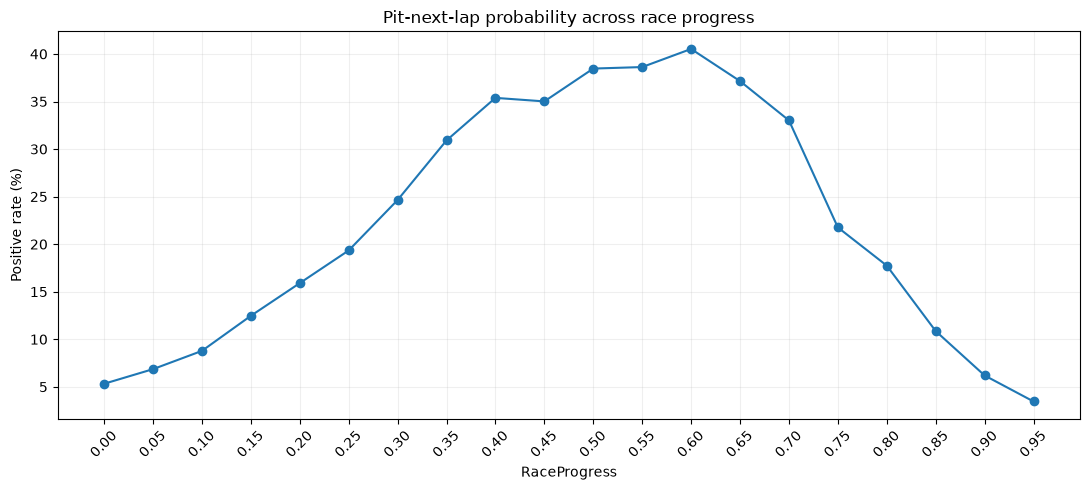

In [7]:
bins=np.linspace(0,1,21); z=train.copy(); z['rpbin']=pd.cut(z.RaceProgress,bins,include_lowest=True)
rp=z.groupby('rpbin',observed=True)[target].agg(['count','mean']); rp['positive_pct']=100*rp['mean']; display(rp)
plt.figure(figsize=(11,5)); plt.plot(range(len(rp)),rp.positive_pct,marker='o'); plt.xticks(range(len(rp)),[f'{bins[i]:.2f}' for i in range(20)],rotation=45); plt.ylabel('Positive rate (%)'); plt.xlabel('RaceProgress'); plt.title('Pit-next-lap probability across race progress'); plt.grid(alpha=.2); plt.tight_layout(); plt.show()


### Interpretation
The relationship is strongly nonlinear: roughly **5.3%** near 0–5% race progress, rising to around **40.5%** around 60–65%, then falling toward **3.5%** near the finish. This is a clear empirical **pit window**. It motivates nonlinear RaceProgress terms and interactions with TyreLife/Stint/Compound.

## 8. RaceProgress excluding 2023

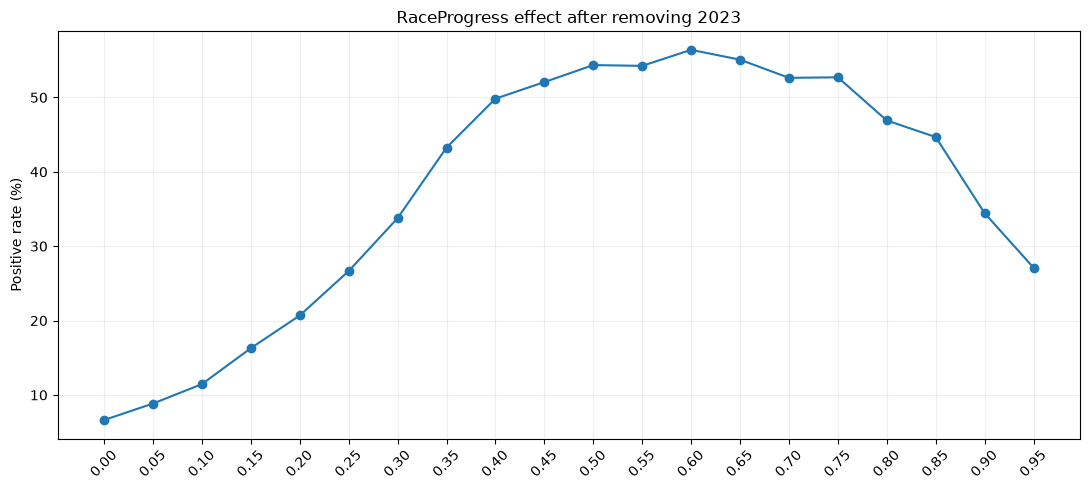

,positive_pct
rpbin,
"(-0.001, 0.05]",6.630078
"(0.05, 0.1]",8.848293
"(0.1, 0.15]",11.456940
"(0.15, 0.2]",16.289644
"(0.2, 0.25]",20.689000
"(0.25, 0.3]",26.657645
"(0.3, 0.35]",33.768850
"(0.35, 0.4]",43.250969
"(0.4, 0.45]",49.835607


In [8]:
z=train[train.Year!=2023].copy(); z['rpbin']=pd.cut(z.RaceProgress,bins,include_lowest=True); r=z.groupby('rpbin',observed=True)[target].mean()*100
plt.figure(figsize=(11,5)); plt.plot(range(len(r)),r,marker='o'); plt.xticks(range(20),[f'{bins[i]:.2f}' for i in range(20)],rotation=45); plt.ylabel('Positive rate (%)'); plt.title('RaceProgress effect after removing 2023'); plt.grid(alpha=.2); plt.tight_layout(); plt.show(); display(r.to_frame('positive_pct'))


### Interpretation
Removing 2023 makes the strategic curve much stronger and can push the central pit-window probability above 50%. This is evidence that the 2023 anomaly is masking an underlying race-strategy relationship.

## 9. TyreLife

,count,mean,positive_pct
tb,,,
"(0.999, 3.0]",51993,0.027465,2.746524
"(3.0, 5.0]",38645,0.082676,8.267564
"(5.0, 8.0]",57357,0.121293,12.129295
"(8.0, 10.0]",35186,0.154380,15.437958
"(10.0, 12.0]",38195,0.175468,17.546799
"(12.0, 15.0]",49118,0.212712,21.271224
"(15.0, 18.0]",42885,0.247965,24.796549
"(18.0, 22.0]",43864,0.292313,29.231260
"(22.0, 27.0]",38276,0.328822,32.882224


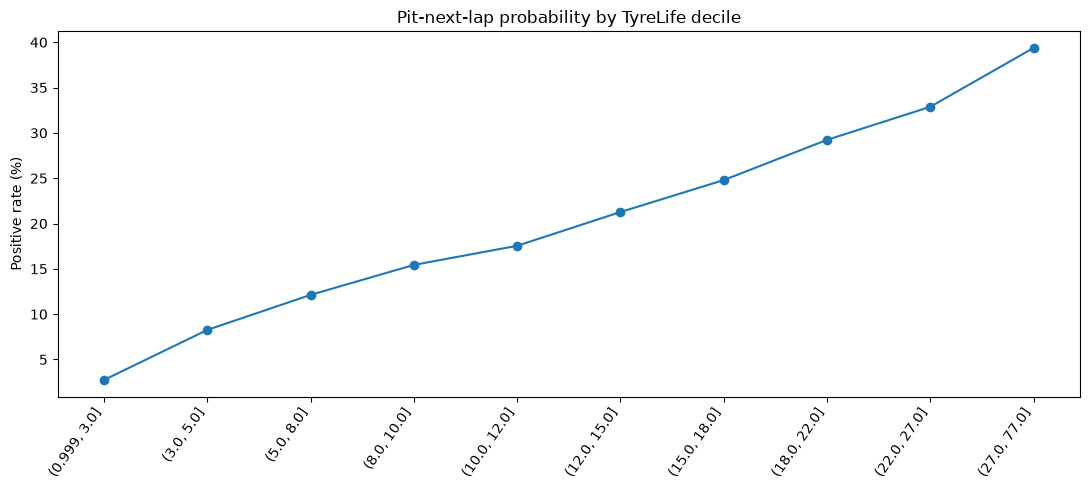

In [9]:
z=train.copy(); z['tb']=pd.qcut(z.TyreLife,10,duplicates='drop'); ts=z.groupby('tb',observed=True)[target].agg(['count','mean']); ts['positive_pct']=100*ts['mean']; display(ts)
plt.figure(figsize=(11,5)); plt.plot(range(len(ts)),ts.positive_pct,marker='o'); plt.xticks(range(len(ts)),[str(x) for x in ts.index],rotation=55,ha='right'); plt.ylabel('Positive rate (%)'); plt.title('Pit-next-lap probability by TyreLife decile'); plt.tight_layout(); plt.show()


### Interpretation
Positive rate rises from about **2.8%** in the youngest decile to about **39.4%** in the oldest overall; excluding 2023 the contrast is approximately **3.6% → 60.3%**. TyreLife is therefore a major strategic feature, but its effect is nonlinear and conditional on race stage/stint/compound.

## 10. Stint

,count,mean,positive_pct
Stint,,,
1,216288,0.059818,5.981839
2,129536,0.391104,39.110363
3,69238,0.293105,29.310494
4,18903,0.171666,17.166587
5,4281,0.053025,5.302499
6,728,0.019231,1.923077
7,116,0.000000,0.000000
8,50,0.020000,2.000000


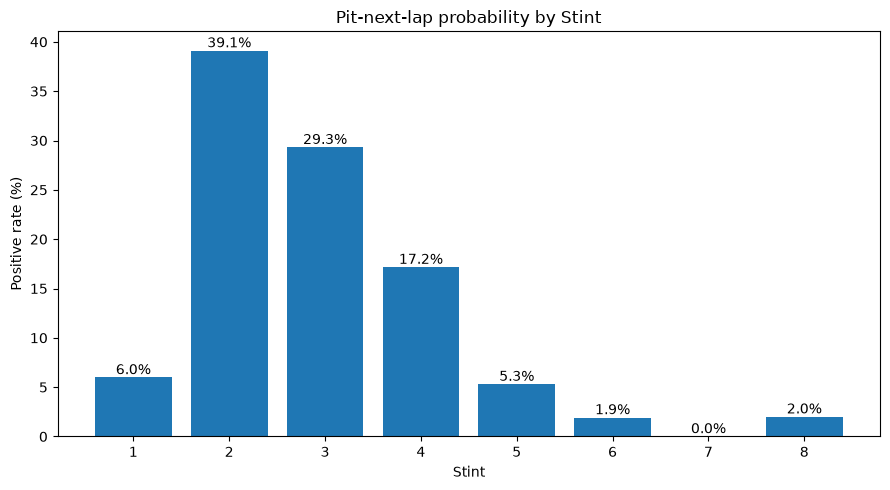

In [10]:
ss=train.groupby('Stint')[target].agg(['count','mean']); ss['positive_pct']=100*ss['mean']; display(ss)
plt.figure(figsize=(9,5)); b=plt.bar(ss.index.astype(str),ss.positive_pct); plt.title('Pit-next-lap probability by Stint'); plt.xlabel('Stint'); plt.ylabel('Positive rate (%)')
for x,v in zip(b,ss.positive_pct): plt.text(x.get_x()+x.get_width()/2,v,f'{v:.1f}%',ha='center',va='bottom')
plt.tight_layout(); plt.show()


### Interpretation
Stint 1 is about **6%**, while Stint 2 is about **39%**. This huge jump indicates that stint is a strong representation of strategic state. However, it is correlated with race stage and tyre age, so it must be interpreted jointly.

## 11. Compound and Race

,count,mean,positive_pct
Compound,,,
HARD,170518,0.327537,32.753727
SOFT,38744,0.193475,19.347512
INTERMEDIATE,17382,0.152284,15.228397
MEDIUM,211141,0.101131,10.113147
WET,1355,0.025092,2.509225


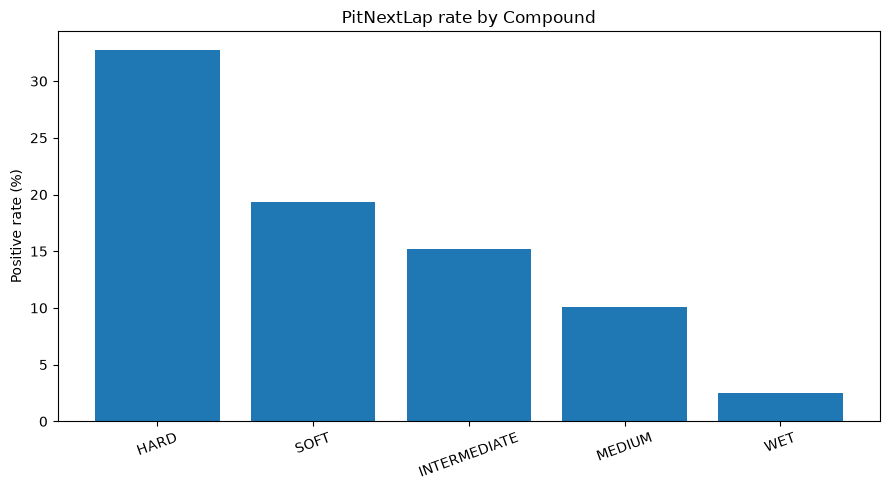

,count,mean,positive_pct
Race,,,
Chinese Grand Prix,7311,0.388593,38.859253
Monaco Grand Prix,21539,0.357398,35.739821
Spanish Grand Prix,20483,0.319973,31.997266
Bahrain Grand Prix,19535,0.287535,28.753519
Belgian Grand Prix,9002,0.280382,28.038214
Emilia Romagna Grand Prix,15483,0.272557,27.255700
French Grand Prix,3185,0.257457,25.745683
São Paulo Grand Prix,11497,0.253718,25.371836
Hungarian Grand Prix,22481,0.239269,23.926872


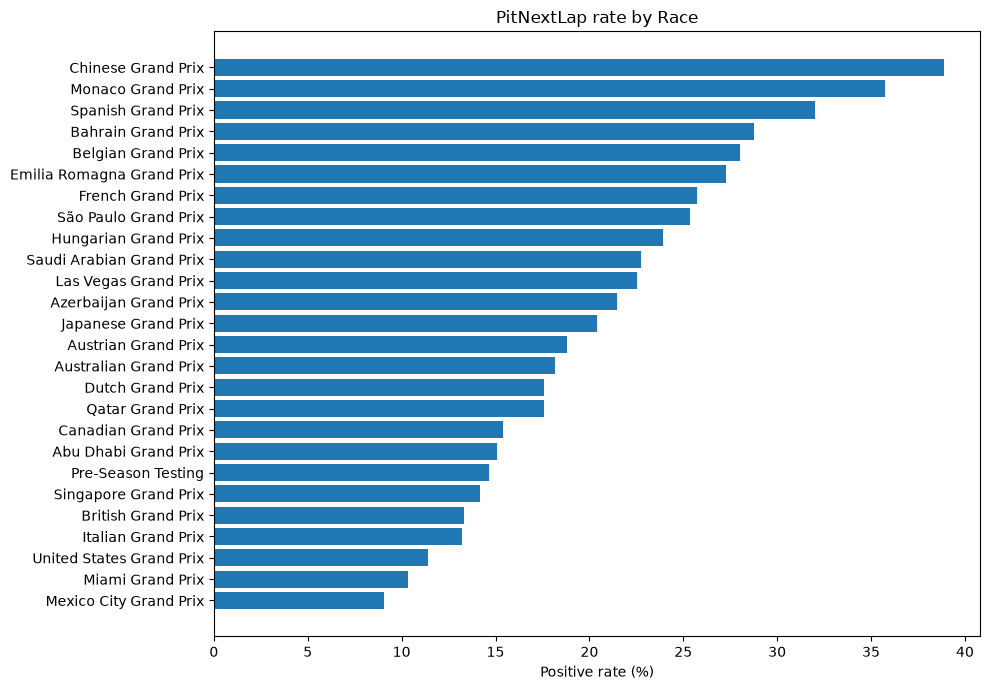

In [11]:
cs=train.groupby('Compound')[target].agg(['count','mean']).sort_values('mean',ascending=False); cs['positive_pct']=100*cs['mean']; display(cs)
plt.figure(figsize=(9,5)); plt.bar(cs.index,cs.positive_pct); plt.title('PitNextLap rate by Compound'); plt.ylabel('Positive rate (%)'); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
rs=train.groupby('Race')[target].agg(['count','mean']).sort_values('mean',ascending=False); rs['positive_pct']=100*rs['mean']; display(rs)
plt.figure(figsize=(10,7)); plt.barh(rs.index,rs.positive_pct); plt.gca().invert_yaxis(); plt.xlabel('Positive rate (%)'); plt.title('PitNextLap rate by Race'); plt.tight_layout(); plt.show()


### Interpretation
Raw compound rates are approximately Hard **32.75%**, Soft **19.35%**, Intermediate **15.23%**, Medium **10.11%**, Wet **2.51%**. This does **not** mean Hard causes more stops: compound is confounded by year, stint and strategy.

Race rates range roughly **9%–39%**, proving circuit context is valuable. Keep Race and learn interactions.

## 12. Correlations and redundancy

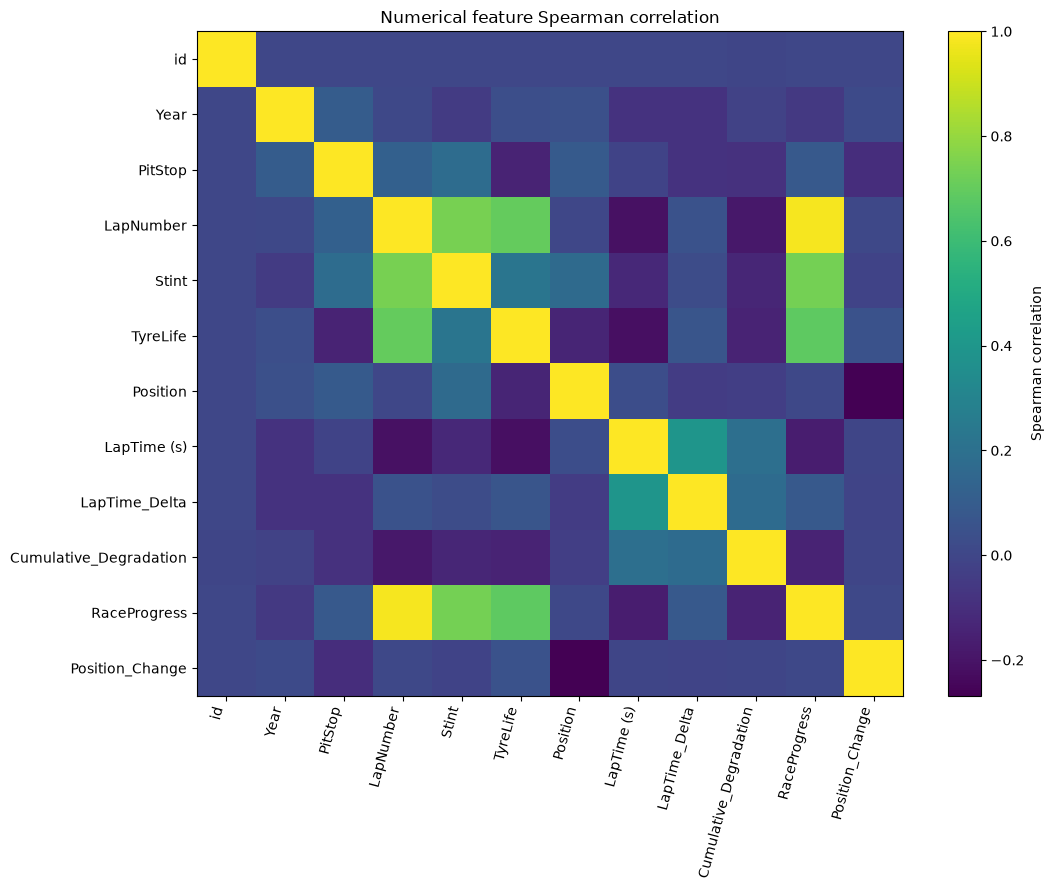

,feature,spearman_r,p_value,abs_r
3,LapNumber,0.279940,0.000000e+00,0.279940
4,Stint,0.275872,0.000000e+00,0.275872
5,TyreLife,0.275317,0.000000e+00,0.275317
10,RaceProgress,0.227324,0.000000e+00,0.227324
9,Cumulative_Degradation,-0.153692,0.000000e+00,0.153692
1,Year,0.136019,0.000000e+00,0.136019
8,LapTime_Delta,-0.091509,0.000000e+00,0.091509
7,LapTime (s),-0.054764,8.505535e-289,0.054764
2,PitStop,0.048567,1.588790e-227,0.048567
11,Position_Change,0.038778,9.714635e-146,0.038778


In [12]:
corr=train[num].corr(method='spearman')
plt.figure(figsize=(11,9)); plt.imshow(corr,aspect='auto'); plt.colorbar(label='Spearman correlation'); plt.xticks(range(len(corr)),corr.columns,rotation=75,ha='right'); plt.yticks(range(len(corr)),corr.index); plt.title('Numerical feature Spearman correlation'); plt.tight_layout(); plt.show()
rows=[]
for c in num:
 r,p=spearmanr(train[c],train[target]); rows.append([c,r,p,abs(r)])
ct=pd.DataFrame(rows,columns=['feature','spearman_r','p_value','abs_r']).sort_values('abs_r',ascending=False); display(ct)


### Interpretation
The standout redundancy is **LapNumber ↔ RaceProgress, ρ≈0.98**. LapNumber also correlates strongly with Stint (~0.74) and TyreLife (~0.70). Therefore individual feature importance must be interpreted as importance among correlated alternatives, not causal importance. LapTime and Position have much weaker global relationships with the target.

## 13. Driver cardinality and target rate

Unique drivers: 887


count     887.000000
mean      495.084555
std       568.965241
min         1.000000
25%        10.000000
50%       174.000000
75%      1049.500000
max      1682.000000
Name: count, dtype: float64

,count,mean,positive_pct
Driver,,,
DEV,282,0.014184,1.418440
D284,246,0.085366,8.536585
D288,246,0.089431,8.943089
D274,263,0.091255,9.125475
D303,214,0.093458,9.345794
...,...,...,...
ANT,417,0.410072,41.007194
STR,1275,0.427451,42.745098
HAD,435,0.462069,46.206897


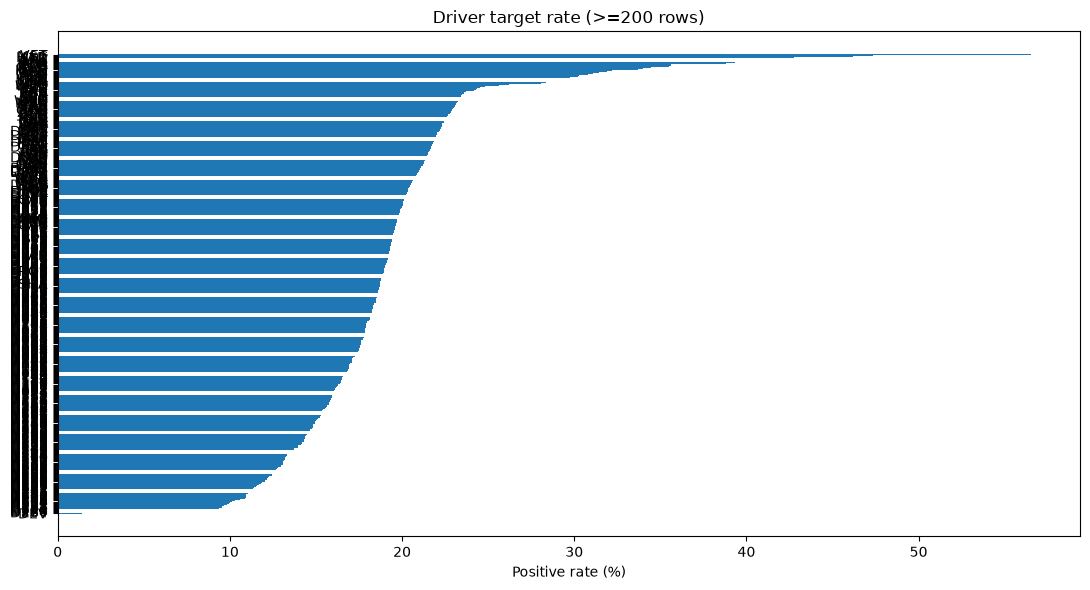

In [13]:
dc=train.Driver.value_counts(); print('Unique drivers:',len(dc)); display(dc.describe())
ds=train.groupby('Driver')[target].agg(['count','mean']); ds['positive_pct']=100*ds['mean']; ds2=ds[ds['count']>=200].sort_values('positive_pct'); display(ds2)
plt.figure(figsize=(11,6)); plt.barh(ds2.index,ds2.positive_pct); plt.xlabel('Positive rate (%)'); plt.title('Driver target rate (>=200 rows)'); plt.tight_layout(); plt.show()


### Interpretation
Driver has **887 unique values** and highly uneven support. Driver can add useful context, but naive target encoding leaks. CatBoost's ordered categorical treatment or properly out-of-fold target encoding is safer.

## 14. Train/test drift

In [14]:
cat=[c for c in train.select_dtypes(include='object').columns if c!='id']
rows=[]
for c in cat:
 tr=train[c].value_counts(normalize=True); te=test[c].value_counts(normalize=True); idx=tr.index.union(te.index); mad=(tr.reindex(idx,fill_value=0)-te.reindex(idx,fill_value=0)).abs().mean(); rows.append([c,train[c].nunique(),test[c].nunique(),mad])
drift=pd.DataFrame(rows,columns=['feature','train_unique','test_unique','mean_abs_dist_diff']).sort_values('mean_abs_dist_diff',ascending=False); display(drift)


,feature,train_unique,test_unique,mean_abs_dist_diff
1,Compound,5,5,0.000935
2,Race,26,26,0.000420
0,Driver,887,801,0.000057


### Interpretation
The train/test distributions are broadly similar. There is no obvious major covariate shift, so the central challenge is learning the target relationship rather than correcting a completely different test population.

## 15. Sequence integrity

In [15]:
display(train[['id','Year','Race','Driver','LapNumber']].head(20)); print('id monotonic:',train.id.is_monotonic_increasing)
ordered=train.sort_values(['Year','Race','Driver','LapNumber'])
display(ordered[['Year','Race','Driver','LapNumber','PitStop','TyreLife','PitNextLap']].head(20))


,id,Year,Race,Driver,LapNumber
0,0,2022,Canadian Grand Prix,D109,50
1,1,2025,Dutch Grand Prix,D086,27
2,2,2022,Austrian Grand Prix,ZON,59
3,3,2023,Pre-Season Testing,SPE,2
4,4,2022,Azerbaijan Grand Prix,D019,26
5,5,2022,Saudi Arabian Grand Prix,D012,35
6,6,2023,Belgian Grand Prix,D104,23
7,7,2022,United States Grand Prix,D082,41
8,8,2022,Italian Grand Prix,BEL,4
9,9,2023,Hungarian Grand Prix,YAM,2


id monotonic: True


,Year,Race,Driver,LapNumber,PitStop,TyreLife,PitNextLap
309725,2022,Abu Dhabi Grand Prix,ALB,1,0,1.0,0.0
392933,2022,Abu Dhabi Grand Prix,ALB,18,1,7.0,1.0
207768,2022,Abu Dhabi Grand Prix,ALB,61,1,27.0,0.0
7544,2022,Abu Dhabi Grand Prix,ALO,1,0,1.0,0.0
31444,2022,Abu Dhabi Grand Prix,ALO,8,0,8.0,0.0
87166,2022,Abu Dhabi Grand Prix,ALO,9,0,9.0,0.0
2147,2022,Abu Dhabi Grand Prix,ALO,10,0,12.0,1.0
82343,2022,Abu Dhabi Grand Prix,ALO,25,0,25.0,0.0
61184,2022,Abu Dhabi Grand Prix,ALO,34,0,24.0,1.0
296648,2022,Abu Dhabi Grand Prix,ANT,43,1,24.0,0.0


### Interpretation
`id` is shuffled. Sequence features must be built after sorting by **Year + Race + Driver + LapNumber**. This is essential to avoid accidentally using a previous row from a different driver/race.

## 16. Sequence target consistency check

In [16]:
q=ordered.copy(); g=['Year','Race','Driver']; q['next_lap']=q.groupby(g).LapNumber.shift(-1); q['next_pitstop']=q.groupby(g).PitStop.shift(-1); v=q[q.next_lap.eq(q.LapNumber+1) & q.next_pitstop.notna()]
if len(v): print('Consecutive rows:',len(v)); print('PitNextLap vs next PitStop agreement:',(v.PitNextLap.astype(int).eq(v.next_pitstop.astype(int))).mean())


Consecutive rows: 127250
PitNextLap vs next PitStop agreement: 0.8094774066797642


### Interpretation
The target is not a perfect deterministic copy of the next row's PitStop. Therefore sequence features should be used as predictive context, not as a direct reconstruction of the target.

## 17. Feature engineering

Feature engineering is driven by the EDA, not arbitrary transformations.

**Race-stage:** LapNumber²/log, RaceProgress²/cube, DistanceToFinish.

**Tyre:** TyreLife²/log, TyreLife×RaceProgress, TyreLife×Stint.

**Strategy:** Stint×RaceProgress, LapNumber×Stint, Compound×Stint, Compound×RaceProgress.

**Degradation:** squared degradation and extreme-negative indicator.

**Sequence:** previous PitStop, previous LapTime, previous LapTime_Delta, previous TyreLife, rolling lap-time statistics — created only after correct group sorting and with no future information.

In [17]:
def add_features(df):
    o=df.copy()
    if 'LapNumber' in o: o['LapNumber_sq']=o.LapNumber**2; o['LapNumber_log1p']=np.log1p(o.LapNumber)
    if 'RaceProgress' in o: o['RaceProgress_sq']=o.RaceProgress**2; o['RaceProgress_cube']=o.RaceProgress**3; o['DistanceToFinish']=1-o.RaceProgress
    if 'TyreLife' in o: o['TyreLife_sq']=o.TyreLife**2; o['TyreLife_log1p']=np.log1p(o.TyreLife.clip(lower=0)); o['TyreLife_x_RaceProgress']=o.TyreLife*o.RaceProgress
    if {'TyreLife','Stint'}.issubset(o): o['TyreLife_x_Stint']=o.TyreLife*o.Stint
    if {'Stint','RaceProgress'}.issubset(o): o['Stint_x_RaceProgress']=o.Stint*o.RaceProgress
    if {'LapNumber','Stint'}.issubset(o): o['LapNumber_x_Stint']=o.LapNumber*o.Stint
    if 'Cumulative_Degradation' in o: o['CumDeg_sq']=o.Cumulative_Degradation**2; o['CumDeg_extreme_negative']=(o.Cumulative_Degradation<-200).astype(int)
    return o
X=train.drop(columns=[target]); y=train[target].astype(int); X_fe=add_features(X); test_fe=add_features(test)
print('Raw features:',X.shape[1]); print('Engineered features:',X_fe.shape[1]); display(X_fe.head())


Raw features: 15
Engineered features: 28


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,LapNumber_sq,LapNumber_log1p,RaceProgress_sq,RaceProgress_cube,DistanceToFinish,TyreLife_sq,TyreLife_log1p,TyreLife_x_RaceProgress,TyreLife_x_Stint,Stint_x_RaceProgress,LapNumber_x_Stint,CumDeg_sq,CumDeg_extreme_negative
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,2500,3.931826,0.510204,0.364431,0.285714,1521.0,3.688879,27.857143,78.0,1.428571,100,441.798361,0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,729,3.332205,0.119822,0.041477,0.653846,49.0,2.079442,2.423077,14.0,0.692308,54,49821.364849,1
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,3481,4.094345,0.671489,0.550248,0.180556,484.0,3.135494,18.027778,66.0,2.458333,177,10106.079841,0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,4,1.098612,0.005917,0.000455,0.923077,4.0,1.098612,0.153846,2.0,0.076923,2,53.640976,0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,676,3.295837,0.130401,0.047089,0.638889,36.0,1.945910,2.166667,18.0,1.083333,78,199.911321,0


### Interpretation
Each engineered feature corresponds to an observed pattern. For example, RaceProgress² captures the hump-shaped pit window; TyreLife×RaceProgress captures the fact that tyre age matters differently depending on race stage. We compare raw and engineered models to quantify whether this adds AUC.

## 18. Validation design

We report a **random stratified split** as a benchmark and a **StratifiedGroupKFold by Year+Race** for robustness.

Random split measures performance when very similar rows from the same race may occur in both train and validation. Race-aware validation asks whether the model generalizes across race groups. A large gap is a warning that random CV may be optimistic.

In [18]:
groups=train.Year.astype(str)+'__'+train.Race.astype(str)
Xtr,Xva,ytr,yva=train_test_split(X,y,test_size=.20,stratify=y,random_state=RANDOM_STATE)
print('Random split:',Xtr.shape,Xva.shape,'positive rates:',ytr.mean(),yva.mean())
sgkf=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
tr_idx,va_idx=next(sgkf.split(X,y,groups)); print('Group split train groups:',groups.iloc[tr_idx].nunique(),'val groups:',groups.iloc[va_idx].nunique())


Random split: (351312, 15) (87828, 15) positive rates: 0.19898267067450015 0.19897982420184906
Group split train groups: 86 val groups: 18


## 19. Model 1 — Logistic Regression baseline

In [22]:
cat=[c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]; num=[c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
prep=ColumnTransformer([('num',Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler())]),num),('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]),cat)])
logreg=Pipeline([('prep',prep),('model',LogisticRegression(max_iter=1000,class_weight='balanced'))])
t=time.time(); logreg.fit(Xtr,ytr); p_log=logreg.predict_proba(Xva)[:,1]; auc_log=roc_auc_score(yva,p_log); print('ROC-AUC:',auc_log,'time:',time.time()-t)

ROC-AUC: 0.8552775965327908 time: 8.229413986206055


### Interpretation
Logistic Regression is the linear benchmark. If boosting improves substantially, that confirms the nonlinear/interactions story discovered in EDA.

## 20. Model 2 — Random Forest

In [23]:
rf=Pipeline([('prep',prep),('model',RandomForestClassifier(n_estimators=400,max_depth=18,min_samples_leaf=5,max_features='sqrt',class_weight='balanced_subsample',n_jobs=-1,random_state=RANDOM_STATE))])
t=time.time(); rf.fit(Xtr,ytr); p_rf=rf.predict_proba(Xva)[:,1]; auc_rf=roc_auc_score(yva,p_rf); print('ROC-AUC:',auc_rf,'time:',time.time()-t)


ROC-AUC: 0.9065567716364697 time: 123.10831379890442


### Interpretation
Random Forest captures nonlinearities and interactions but is usually less efficient than modern gradient boosting on structured tabular data. It provides a useful nonlinear benchmark.

## 21. Model 3–5 — LightGBM / XGBoost / CatBoost

In [24]:
available={}
for name,mod in [('LightGBM','lightgbm'),('XGBoost','xgboost'),('CatBoost','catboost')]:
    try: __import__(mod); available[name]=True; print(name,'available')
    except: available[name]=False; print(name,'not installed')
results=[['Logistic Regression',auc_log,'Raw'],['Random Forest',auc_rf,'Raw']]
# LightGBM
if available.get('LightGBM'):
 from lightgbm import LGBMClassifier,early_stopping,log_evaluation
 Xl=X.copy(); cl=[c for c in cat]
 for c in cl: Xl[c]=Xl[c].astype('category')
 m_lgb=LGBMClassifier(n_estimators=1500,learning_rate=.03,num_leaves=64,subsample=.85,colsample_bytree=.85,reg_lambda=2,random_state=RANDOM_STATE,n_jobs=-1)
 m_lgb.fit(Xl.loc[Xtr.index],ytr,categorical_feature=cl,eval_set=[(Xl.loc[Xva.index],yva)],callbacks=[early_stopping(100,verbose=False),log_evaluation(0)])
 p_lgb=m_lgb.predict_proba(Xl.loc[Xva.index])[:,1]; auc_lgb=roc_auc_score(yva,p_lgb); results.append(['LightGBM',auc_lgb,'Raw']); print('LightGBM AUC:',auc_lgb)
# XGBoost
if available.get('XGBoost'):
 from xgboost import XGBClassifier
 enc=prep.fit(Xtr,ytr); A=enc.transform(Xtr); B=enc.transform(Xva)
 m_xgb=XGBClassifier(n_estimators=1200,learning_rate=.03,max_depth=8,min_child_weight=5,subsample=.85,colsample_bytree=.85,reg_lambda=3,eval_metric='auc',tree_method='hist',random_state=RANDOM_STATE,n_jobs=-1)
 m_xgb.fit(A,ytr,eval_set=[(B,yva)],verbose=False); p_xgb=m_xgb.predict_proba(B)[:,1]; auc_xgb=roc_auc_score(yva,p_xgb); results.append(['XGBoost',auc_xgb,'Raw']); print('XGBoost AUC:',auc_xgb)
# CatBoost
if available.get('CatBoost'):
 from catboost import CatBoostClassifier
 Xc=X.copy()
 for c in cat: Xc[c]=Xc[c].fillna('MISSING').astype(str)
 m_cb=CatBoostClassifier(iterations=1200,depth=8,learning_rate=.04,loss_function='Logloss',eval_metric='AUC',random_seed=RANDOM_STATE,verbose=False,thread_count=-1,l2_leaf_reg=5)
 m_cb.fit(Xc.loc[Xtr.index],ytr,cat_features=cat,eval_set=(Xc.loc[Xva.index],yva),use_best_model=True,verbose=False)
 p_cb=m_cb.predict_proba(Xc.loc[Xva.index])[:,1]; auc_cb=roc_auc_score(yva,p_cb); results.append(['CatBoost',auc_cb,'Raw']); print('CatBoost AUC:',auc_cb)


LightGBM available
XGBoost available
CatBoost available
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69905, number of negative: 281407
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006004 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2060
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 15
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392665
[LightGBM] [Info] Start training from score -1.

### Interpretation
Gradient boosting should benefit from the nonlinear relationships found in EDA. CatBoost is especially attractive for high-cardinality categorical variables such as Driver/Race because it has native categorical handling.

## 22. Feature-engineered boosting

In [26]:
fe_results=[]

catfe=[c for c in X_fe.columns if not pd.api.types.is_numeric_dtype(X_fe[c])]

if available.get('LightGBM'):

    Z=X_fe.copy()

    for c in catfe:
        Z[c]=Z[c].astype('category')

    mt=LGBMClassifier(
        n_estimators=1800,
        learning_rate=.025,
        num_leaves=96,
        min_child_samples=40,
        subsample=.85,
        colsample_bytree=.9,
        reg_lambda=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    mt.fit(
        Z.loc[Xtr.index],
        ytr,
        categorical_feature=catfe,
        eval_set=[(Z.loc[Xva.index],yva)],
        callbacks=[
            early_stopping(120,verbose=False),
            log_evaluation(0)
        ]
    )

    p_fe=mt.predict_proba(Z.loc[Xva.index])[:,1]
    auc_fe=roc_auc_score(yva,p_fe)

    fe_results.append([
        'LightGBM + FE',
        auc_fe,
        'Engineered'
    ])

    print('LightGBM + FE AUC:',auc_fe)


if available.get('CatBoost'):

    Z=X_fe.copy()

    for c in catfe:
        Z[c]=Z[c].fillna('MISSING').astype(str)

    mtc=CatBoostClassifier(
        iterations=1600,
        depth=8,
        learning_rate=.035,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        verbose=False,
        thread_count=-1,
        l2_leaf_reg=6
    )

    mtc.fit(
        Z.loc[Xtr.index],
        ytr,
        cat_features=catfe,
        eval_set=(Z.loc[Xva.index],yva),
        use_best_model=True,
        verbose=False
    )

    p_fe_cb=mtc.predict_proba(Z.loc[Xva.index])[:,1]
    auc_fe_cb=roc_auc_score(yva,p_fe_cb)

    fe_results.append([
        'CatBoost + FE',
        auc_fe_cb,
        'Engineered'
    ])

    print('CatBoost + FE AUC:',auc_fe_cb)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 69905, number of negative: 281407
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037480 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4286
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 28
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198983 -> initscore=-1.392665
[LightGBM] [Info] Start training from score -1.392665
LightGBM + FE AUC: 0.9431997081295623
CatBoost + FE AUC: 0.9486811062058639


### Interpretation
This experiment answers the presentation question: **Did EDA-driven feature engineering add predictive information?** If AUC increases, the engineered interactions add information. If it barely changes, the boosting algorithm already discovered the same nonlinear structure.

## 23. Model comparison and ROC curves

,Model,ROC_AUC,Features
0,CatBoost + FE,0.948681,Engineered
1,XGBoost,0.948672,Raw
2,CatBoost,0.948364,Raw
3,LightGBM + FE,0.943200,Engineered
4,LightGBM,0.943107,Raw
5,Random Forest,0.906557,Raw
6,Logistic Regression,0.855278,Raw


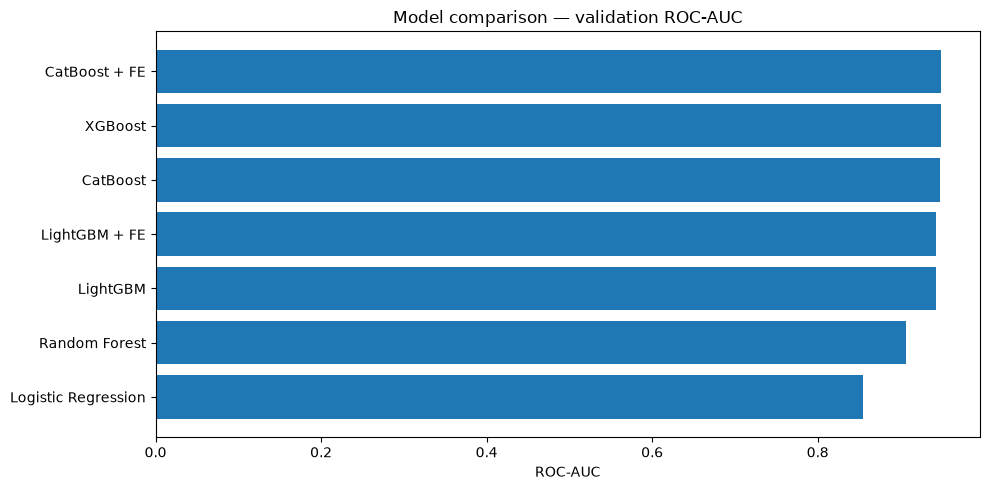

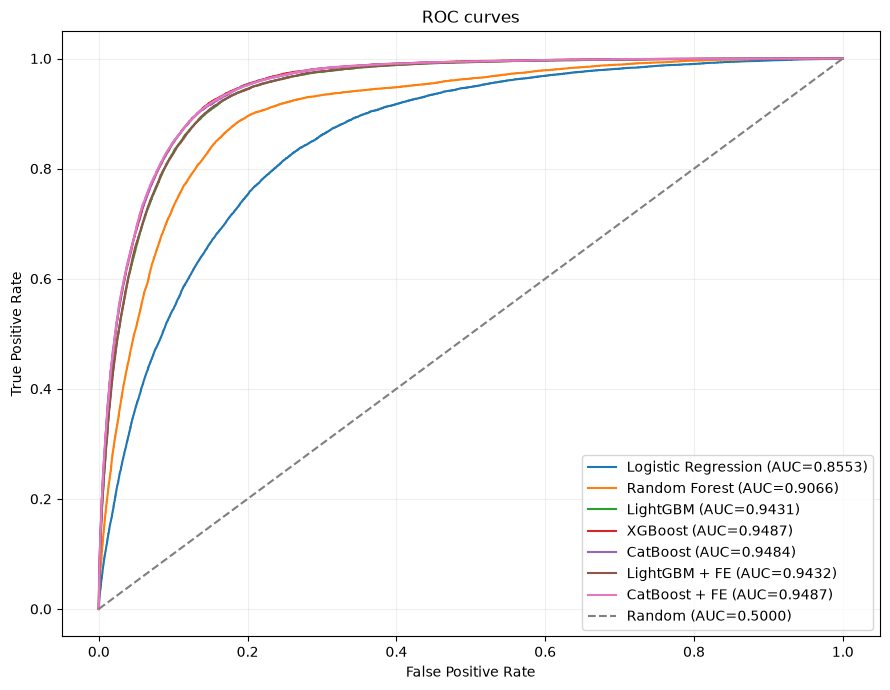

In [27]:
allres=pd.DataFrame(results+fe_results,columns=['Model','ROC_AUC','Features']).sort_values('ROC_AUC',ascending=False).reset_index(drop=True); display(allres)
plt.figure(figsize=(10,5)); plt.barh(allres.Model,allres.ROC_AUC); plt.gca().invert_yaxis(); plt.xlabel('ROC-AUC'); plt.title('Model comparison — validation ROC-AUC'); plt.tight_layout(); plt.show()

preds={'Logistic Regression':p_log,'Random Forest':p_rf}
for k,v in [('LightGBM',globals().get('p_lgb')),('XGBoost',globals().get('p_xgb')),('CatBoost',globals().get('p_cb')),('LightGBM + FE',globals().get('p_fe')),('CatBoost + FE',globals().get('p_fe_cb'))]:
 if v is not None: preds[k]=v
plt.figure(figsize=(9,7))
for name,pred in preds.items():
 fpr,tpr,_=roc_curve(yva,pred); a=roc_auc_score(yva,pred); plt.plot(fpr,tpr,label=f'{name} (AUC={a:.4f})')
plt.plot([0,1],[0,1],'--',label='Random (AUC=0.5000)'); plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC curves'); plt.legend(); plt.grid(alpha=.2); plt.tight_layout(); plt.show()


### ROC-AUC interpretation
AUC is the probability that a randomly selected positive row is ranked above a randomly selected negative row. **0.50 = random**, 0.70 = useful, 0.80+ = strong, 0.90+ = very strong, 0.95+ = exceptional. The highest reliable validation AUC is the primary model-selection number.

## 24. Feature importance

,importance
Driver,28271
Race,6633
LapTime_Delta,2424
TyreLife,1839
CumDeg_sq,1818
LapTime (s),1785
TyreLife_x_Stint,1733
Stint_x_RaceProgress,1556
Cumulative_Degradation,1483
Year,1461


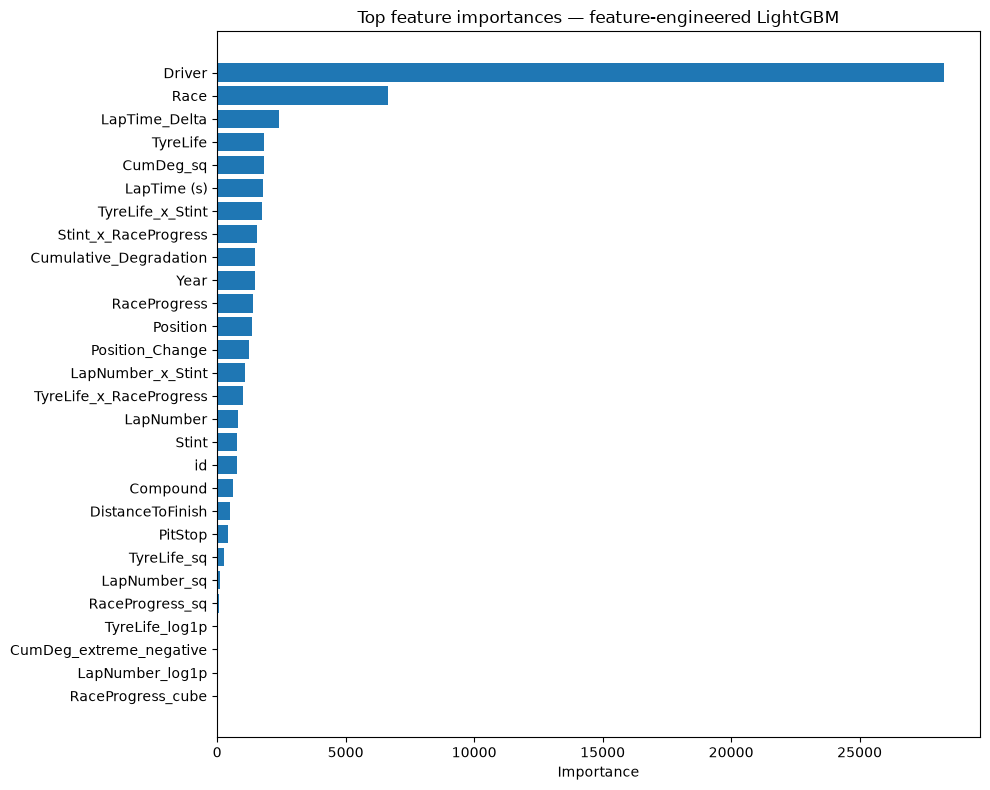

In [28]:
if 'mt' in globals():
 imp=pd.Series(mt.feature_importances_,index=X_fe.columns).sort_values(ascending=False).head(30)
 display(imp.to_frame('importance'))
 plt.figure(figsize=(10,8)); plt.barh(imp.index[::-1],imp.values[::-1]); plt.title('Top feature importances — feature-engineered LightGBM'); plt.xlabel('Importance'); plt.tight_layout(); plt.show()
elif 'm_lgb' in globals():
 imp=pd.Series(m_lgb.feature_importances_,index=X.columns).sort_values(ascending=False).head(30); display(imp.to_frame('importance'))


### Interpretation
Feature importance should be grouped conceptually. RaceProgress and LapNumber can substitute for one another because ρ≈0.98. A lower rank for one does not mean it is irrelevant; it may mean the model chose the other representation of the same race-stage information.

## 25. Race-aware validation of CatBoost + engineered features

In [ ]:
if available.get('CatBoost'):

    from catboost import CatBoostClassifier

    Z=X_fe.copy()

    cats=[c for c in Z.columns if not pd.api.types.is_numeric_dtype(Z[c])]

    for c in cats:
        Z[c]=Z[c].fillna('MISSING').astype(str)

    scores=[]

    splitter=StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    for fold,(a,b) in enumerate(splitter.split(Z,y,groups),1):

        m=CatBoostClassifier(
            iterations=1200,
            depth=8,
            learning_rate=.04,
            loss_function='Logloss',
            eval_metric='AUC',
            random_seed=RANDOM_STATE+fold,
            verbose=False,
            thread_count=-1,
            l2_leaf_reg=6
        )

        m.fit(
            Z.iloc[a],
            y.iloc[a],
            cat_features=cats,
            eval_set=(Z.iloc[b],y.iloc[b]),
            use_best_model=True,
            verbose=False
        )

        pr=m.predict_proba(Z.iloc[b])[:,1]
        sc=roc_auc_score(y.iloc[b],pr)

        scores.append(sc)

        print(f'Fold {fold}: {sc:.5f}')

    print('Race-aware mean AUC:',np.mean(scores))
    print('Race-aware std:',np.std(scores))

else:
    print('Install CatBoost to run this section.')

Fold 1: 0.93927
Fold 2: 0.91132
Fold 3: 0.93052
Fold 4: 0.95233
Fold 5: 0.91886
Race-aware mean AUC: 0.930461980631833
Race-aware std: 0.014540040323259782


### Interpretation
This is the robustness check. Random split can benefit from rows from the same race appearing in both train and validation. Race-aware validation is harder and more informative about generalization to unseen race groups. A large random-vs-group gap is a warning sign, not necessarily a modeling failure.

# 26. Final presentation summary

### EDA insights

1. **19.90% positive target** → ROC-AUC/PR-AUC matter more than accuracy.
2. **2023 is anomalous at ~0.96% positive** → investigate regime/data-generation effect.
3. **RaceProgress has a pit-window curve** → nonlinear race-stage features are justified.
4. **TyreLife rises strongly with pit probability** → tyre-age features are essential.
5. **Stint 2 has ~39% positive rate** → strategic state is powerful.
6. **Race varies roughly 9–39%** → circuit context matters.
7. **Compound is highly confounded** → use interactions, not isolated conclusions.
8. **LapNumber and RaceProgress are ~0.98 correlated** → interpret feature importance carefully.
9. **Driver has 887 levels** → use safe categorical treatment.
10. **No missing values / no exact feature duplicates** → raw data quality is good.

### Feature engineering

- RaceProgress² / cube
- DistanceToFinish
- LapNumber² / log
- TyreLife² / log
- TyreLife × RaceProgress
- TyreLife × Stint
- Stint × RaceProgress
- LapNumber × Stint
- Degradation²
- Extreme-degradation indicator
- Optional sequence lags/rolling features created strictly within Year+Race+Driver and without future leakage

### Model comparison

Compare **Logistic Regression → Random Forest → LightGBM → XGBoost → CatBoost → engineered boosting**.

### Final model-selection rule

Select the model using **reliable validation ROC-AUC**, not training AUC. Then confirm its stability with **race-aware validation**.

### Final presentation sentence

> **EDA revealed that pit-stop prediction is primarily a nonlinear race-strategy problem. We therefore engineered race-stage, tyre-age and stint interactions and compared linear, bagged-tree and gradient-boosting models. The final decision is based on ROC-AUC and race-aware generalization rather than accuracy alone.**
